In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Everything works!")

Everything works!


In [21]:
portfolio = pd.read_csv("../data/processed/cleaned_portfolio.csv")

portfolio.head()

,date,RELIANCE,TCS,HDFCBANK,INFY,ICICIBANK,WIPRO,BAJFINANCE,HCLTECH,market_nifty50
0,2025-01-02,2396.73,3793.18,1648.56,1496.77,1018.86,489.17,7241.65,1315.76,16967.46
1,2025-01-03,2402.81,3809.43,1678.65,1512.71,1021.36,484.14,7137.23,1321.67,17196.66
2,2025-01-06,2406.23,3806.40,1693.38,1480.94,1017.39,488.09,7236.45,1317.96,17056.49
3,2025-01-07,2417.11,3854.11,1666.46,1494.75,995.09,469.30,7176.36,1300.91,17131.40
4,2025-01-08,2443.13,3786.72,1688.97,1473.48,994.60,467.61,7194.42,1317.93,17095.76


In [22]:
portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            180 non-null    str    
 1   RELIANCE        180 non-null    float64
 2   TCS             180 non-null    float64
 3   HDFCBANK        180 non-null    float64
 4   INFY            180 non-null    float64
 5   ICICIBANK       180 non-null    float64
 6   WIPRO           180 non-null    float64
 7   BAJFINANCE      180 non-null    float64
 8   HCLTECH         180 non-null    float64
 9   market_nifty50  180 non-null    float64
dtypes: float64(9), str(1)
memory usage: 14.2 KB


In [23]:
portfolio.describe()

,RELIANCE,TCS,HDFCBANK,INFY,ICICIBANK,WIPRO,BAJFINANCE,HCLTECH,market_nifty50
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,2410.266167,3735.705056,1711.285556,1518.772778,1179.627167,512.669722,6744.819056,1521.757444,17011.402333
std,172.971038,230.175854,140.810573,148.233047,99.533291,34.873369,883.371150,106.797820,155.583343
min,1993.980000,3369.300000,1482.300000,1359.770000,982.930000,441.490000,5571.130000,1300.910000,16653.160000
25%,2301.050000,3561.005000,1615.250000,1424.212500,1105.600000,481.620000,5867.150000,1443.635000,16901.132500
50%,2429.395000,3685.785000,1680.280000,1469.425000,1181.560000,521.360000,6824.280000,1539.540000,16999.260000
75%,2572.217500,3896.542500,1755.777500,1531.432500,1264.427500,537.885000,7197.555000,1615.225000,17121.255000
max,2677.490000,4297.080000,2118.890000,1952.300000,1348.530000,582.130000,8677.070000,1693.020000,17455.360000


In [24]:
portfolio.isnull().sum()

date              0
RELIANCE          0
TCS               0
HDFCBANK          0
INFY              0
ICICIBANK         0
WIPRO             0
BAJFINANCE        0
HCLTECH           0
market_nifty50    0
dtype: int64

In [25]:
portfolio.duplicated().sum()

np.int64(0)

In [26]:
portfolio["date"] = pd.to_datetime(portfolio["date"])

In [27]:
portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            180 non-null    datetime64[us]
 1   RELIANCE        180 non-null    float64       
 2   TCS             180 non-null    float64       
 3   HDFCBANK        180 non-null    float64       
 4   INFY            180 non-null    float64       
 5   ICICIBANK       180 non-null    float64       
 6   WIPRO           180 non-null    float64       
 7   BAJFINANCE      180 non-null    float64       
 8   HCLTECH         180 non-null    float64       
 9   market_nifty50  180 non-null    float64       
dtypes: datetime64[us](1), float64(9)
memory usage: 14.2 KB


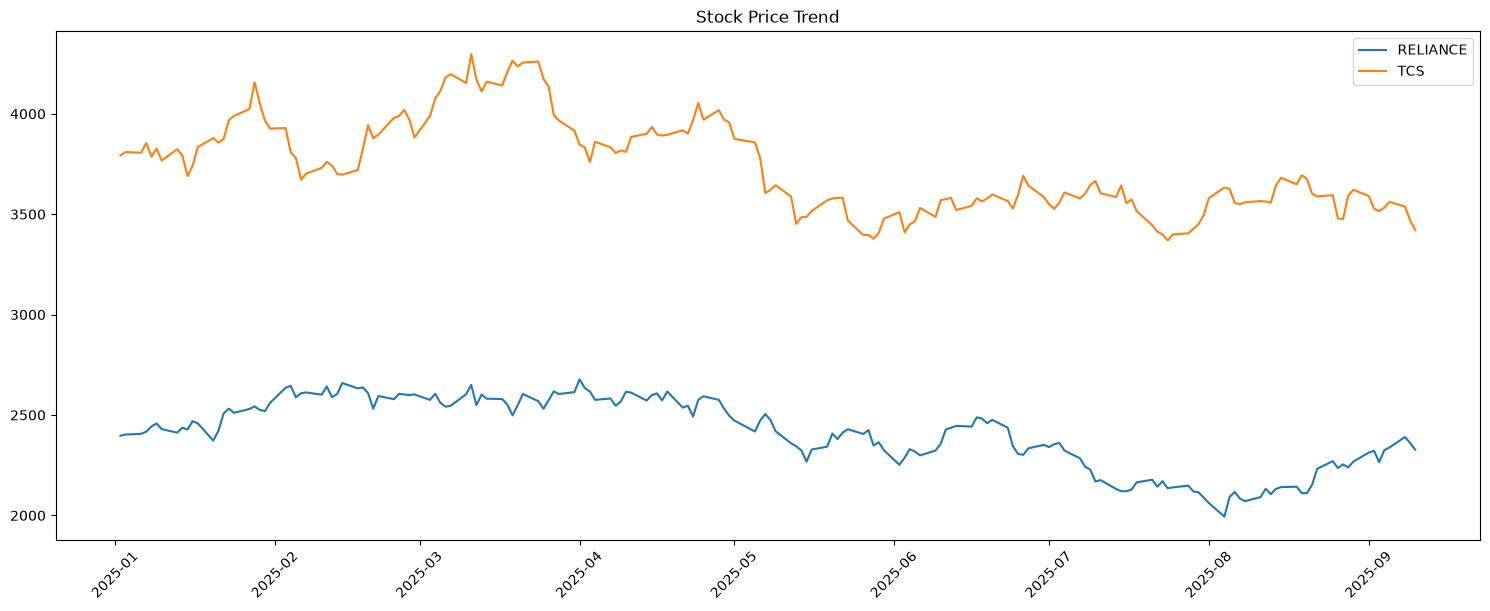

In [28]:
plt.figure(figsize=(15,6))

plt.plot(portfolio["date"], portfolio["RELIANCE"], label="RELIANCE")
plt.plot(portfolio["date"], portfolio["TCS"], label="TCS")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.title("Stock Price Trend")

plt.show()

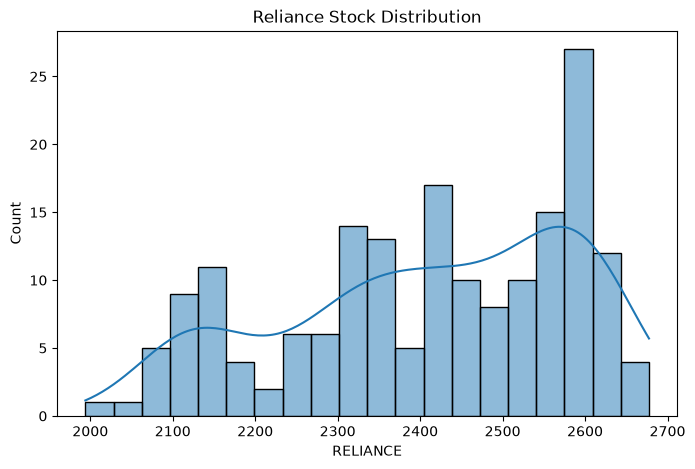

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    portfolio["RELIANCE"],
    bins=20,
    kde=True
)

plt.title("Reliance Stock Distribution")

plt.show()

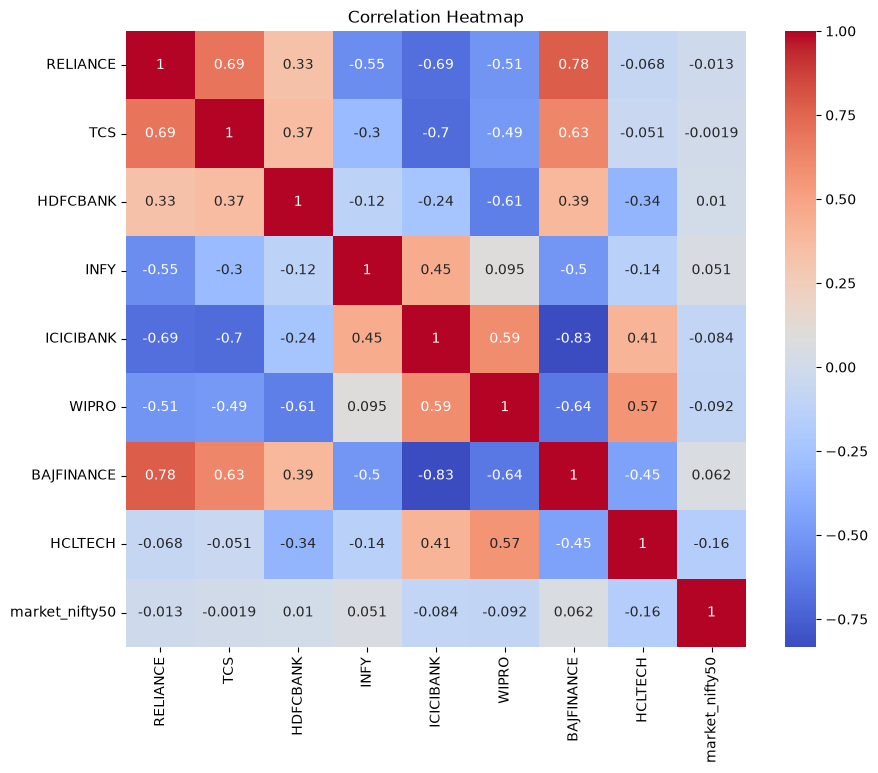

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(
    portfolio.drop(columns=["date"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [31]:
portfolio.mean(numeric_only=True)

RELIANCE           2410.266167
TCS                3735.705056
HDFCBANK           1711.285556
INFY               1518.772778
ICICIBANK          1179.627167
WIPRO               512.669722
BAJFINANCE         6744.819056
HCLTECH            1521.757444
market_nifty50    17011.402333
dtype: float64

In [32]:
portfolio.std(numeric_only=True)

RELIANCE          172.971038
TCS               230.175854
HDFCBANK          140.810573
INFY              148.233047
ICICIBANK          99.533291
WIPRO              34.873369
BAJFINANCE        883.371150
HCLTECH           106.797820
market_nifty50    155.583343
dtype: float64

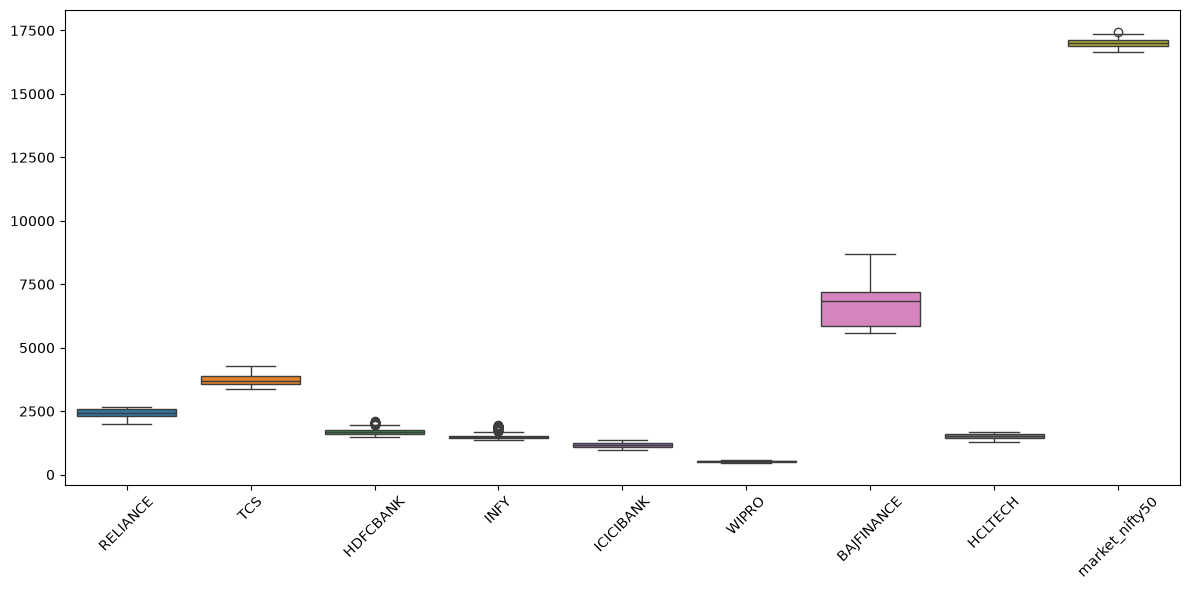

In [33]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=portfolio.drop(columns=["date"])
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [34]:
portfolio.to_csv(
    "../data/processed/cleaned_portfolio.csv",
    index=False
)

In [35]:
import pandas as pd

def preprocess_data(df):

    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])

    df = df.drop_duplicates()

    df = df.fillna(method="ffill")

    return df

In [36]:
portfolio.shape

(180, 10)

# Baseline Report

## Dataset Summary

- Total records:180
- Total features: 10
- Missing values: 0
- Duplicate rows: 0

## Key Findings

- Dataset contains historical stock prices.
- No missing values were detected.
- Date column converted to datetime.
- Correlation heatmap generated.
- RELIANCE and TCS price trends visualized.
- Cleaned dataset saved for model training.